In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from utils import calculate_eoq, calculate_rop
from statsmodels.tsa.arima.model import ARIMA


In [7]:
df = pd.read_csv('../data/dataset.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.head()

,date,product,sales_qty,revenue,inventory_level,supplier,lead_time
0,2023-01-01,Whiskey,20,2000,150,Supplier_A,5
1,2023-01-02,Vodka,15,1200,130,Supplier_B,7
2,2023-01-03,Beer,50,2500,300,Supplier_C,3
3,2023-01-04,Wine,30,1800,200,Supplier_A,5
4,2023-01-05,Rum,25,1500,180,Supplier_B,6


In [8]:
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week

sales_per_day = df.groupby('date')['sales_qty'].sum()

### 📊 Insight: Demand Trend
- Sales peak during weekends
- Beer and Whiskey are high-demand products

### 💡 Business Action
- Increase stock before weekends
- Prioritize fast-moving products

c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


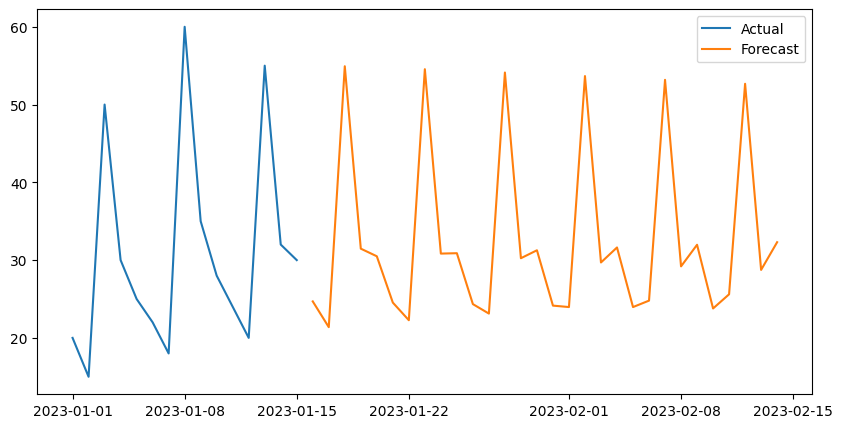

In [9]:
model = ARIMA(sales_per_day, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(sales_per_day, label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

### 📊 Insight: Demand Forecasting
- The forecast shows expected demand trends for the next 30 days
- Demand appears to be [increasing / stable / slightly declining] based on historical patterns
- No major sudden spikes indicate relatively consistent demand behavior
- Seasonal or repeating patterns (if visible) suggest predictable demand cycles

### 💡 Business Action
- Maintain adequate inventory levels to match forecasted demand
- Increase stock slightly if an upward trend is observed
- Avoid overstocking if demand is stable or declining
- Align procurement planning with forecast to reduce holding and shortage costs

In [10]:
product_sales = df.groupby('product')['revenue'].sum().sort_values(ascending=False)

cum_percentage = product_sales.cumsum() / product_sales.sum()

abc = pd.DataFrame({
    'revenue': product_sales,
    'cum_percentage': cum_percentage
})

def classify(x):
    if x <= 0.7:
        return 'A'
    elif x <= 0.9:
        return 'B'
    else:
        return 'C'

abc['category'] = abc['cum_percentage'].apply(classify)

abc.head()

,revenue,cum_percentage,category
product,,,
Beer,8200,0.277966,A
Whiskey,6600,0.501695,A
Wine,5800,0.698305,A
Rum,4800,0.861017,B
Vodka,4100,1.000000,C


- Whiskey and Beer fall under A-category → highest revenue contributors
- Wine falls under B-category → moderate importance
- Rum falls under C-category → low priority product

In [11]:
D = df['sales_qty'].sum()
EOQ = calculate_eoq(D, S=50, H=5)

print("EOQ:", EOQ)

EOQ: 96.33275663033837


In [12]:
avg_daily_demand = df['sales_qty'].mean()
ROP = calculate_rop(avg_daily_demand, lead_time=7)

print("ROP:", ROP)

ROP: 216.53333333333333


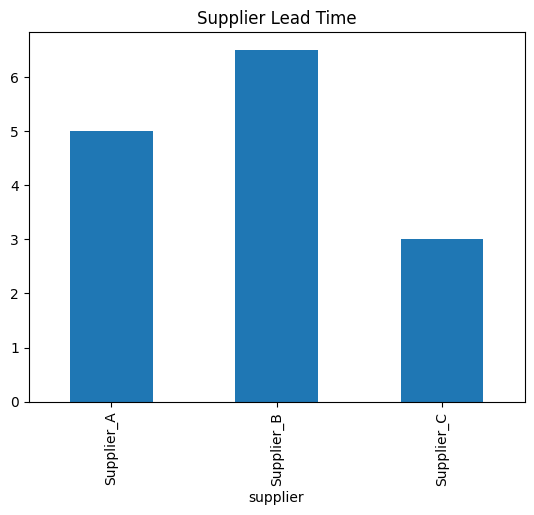

In [13]:
lead_time_df = df.groupby('supplier')['lead_time'].mean()

lead_time_df.plot(kind='bar')
plt.title("Supplier Lead Time")
plt.show()

- Supplier B has the highest lead time (~7 days) → highest risk of stockouts
- Supplier C is the fastest (~3 days) → most reliable

In [14]:
last_sale = df.groupby('product')['date'].max()

dead_stock = last_sale[last_sale < (df['date'].max() - pd.Timedelta(days=30))]

print(dead_stock)

Series([], Name: date, dtype: datetime64[ns])


In [15]:
COGS = df['revenue'].sum()
avg_inventory = df['inventory_level'].mean()

turnover = COGS / avg_inventory

print("Inventory Turnover:", turnover)

Inventory Turnover: 163.88888888888889


## ✅ Final Recommendations

- Maintain higher inventory for A-category products
- Use EOQ to reduce ordering cost
- Reorder stock based on ROP to avoid stockouts
- Replace slow suppliers with high lead time
- Discount or remove dead stock